In [ ]:
# Notebook 06: Final Model Evaluation and Model Comparison

In [ ]:
## Introduction

This notebook presents the final evaluation and comparison of all developed predictive models for heart disease classification.
The objective is to compare the performance of the classical machine learning algorithms and the Deep Learning model using a consistent
set of evaluation metrics.

The notebook summarises experimental findings and identifies the most suitable model for deployment in this study.

In [ ]:
## Objectives

- Load the saved model comparison results.
- Compare all predictive models.
- Visualise model performance.
- Identify the best-performing classifier.
- Summarise the findings for the dissertation.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent

RESULTS_PATH = PROJECT_ROOT / "results"
FIGURES_PATH = PROJECT_ROOT / "Figures"

FIGURES_PATH.mkdir(exist_ok=True)

In [3]:
comparison = pd.read_csv(
    RESULTS_PATH / "model_comparison.csv"
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.8689,0.8125,0.9286,0.8667,0.9513
1,Random Forest,0.9180,0.8710,0.9643,0.9153,0.9535
2,XGBoost,0.8852,0.8182,0.9643,0.8852,0.9470
3,Deep Learning,0.8525,0.8276,0.8571,0.8421,0.9524


In [4]:
comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Random Forest,0.9180,0.8710,0.9643,0.9153,0.9535
2,XGBoost,0.8852,0.8182,0.9643,0.8852,0.9470
0,Logistic Regression,0.8689,0.8125,0.9286,0.8667,0.9513
3,Deep Learning,0.8525,0.8276,0.8571,0.8421,0.9524


In [ ]:
## Accuracy Comparison

The following figure compares the predictive accuracy of all developed models.

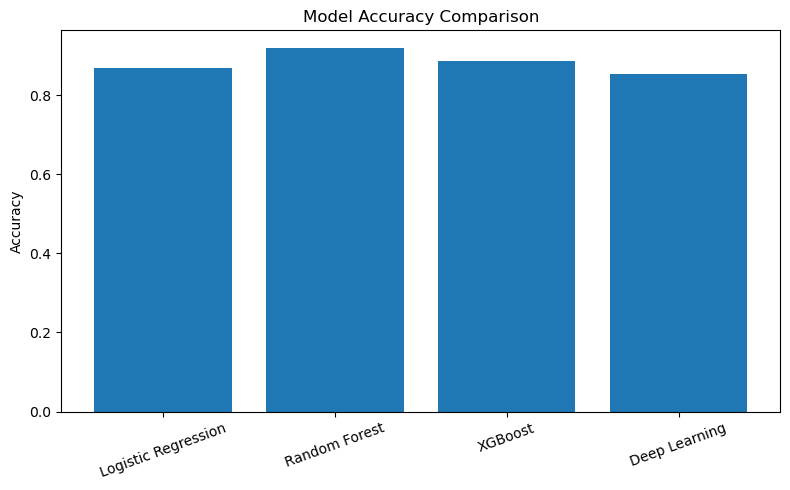

In [5]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
## Performance Comparison

The following table summarises the predictive performance of all developed models using five evaluation metrics.

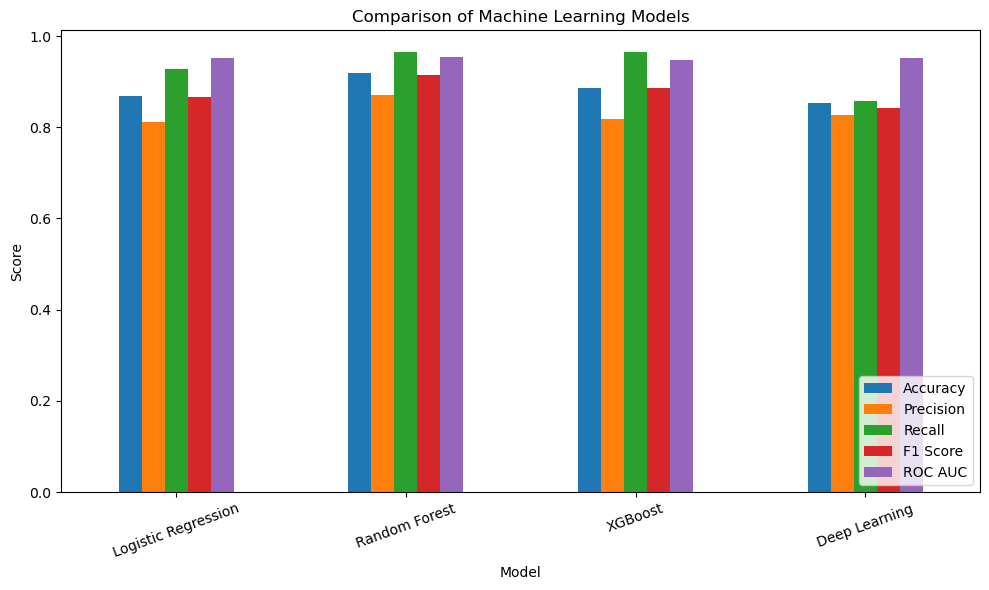

In [6]:
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Score")
plt.title("Comparison of Machine Learning Models")

plt.xticks(rotation=20)

plt.legend(loc="lower right")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "overall_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
best_model = comparison.loc[
    comparison["Accuracy"].idxmax()
]

best_model

Model        Random Forest
Accuracy             0.918
Precision            0.871
Recall              0.9643
F1 Score            0.9153
ROC AUC             0.9535
Name: 1, dtype: object

In [8]:
print("Best Performing Model")
print("----------------------")
print(best_model)

Best Performing Model
----------------------
Model        Random Forest
Accuracy             0.918
Precision            0.871
Recall              0.9643
F1 Score            0.9153
ROC AUC             0.9535
Name: 1, dtype: object


In [ ]:
## Interpretation

The comparative evaluation demonstrates that Random Forest achieved the highest overall predictive performance across the evaluated
machine learning models.

Although the Deep Learning model achieved a competitive ROC-AUC score, its overall accuracy and F1-score were lower than those of
the Random Forest classifier. Logistic Regression provided a strong interpretable baseline, while XGBoost also performed competitively.

These findings indicate that ensemble learning methods are particularly effective for structured clinical datasets such as the
Cleveland Heart Disease dataset.

In [ ]:
# Conclusion

This dissertation successfully developed and evaluated multiple Artificial Intelligence models for heart disease prediction.

The project included:

- Exploratory Data Analysis
- Data Preprocessing
- Classical Machine Learning
- Deep Learning
- Explainable AI using SHAP

Among the evaluated models, Random Forest demonstrated the strongest predictive performance and was selected as the preferred model.

The incorporation of SHAP explainability further enhanced the transparency and interpretability of the predictive system,
supporting its suitability for healthcare applications where explainability is essential.

In [9]:
comparison.to_csv(
    RESULTS_PATH / "final_model_results.csv",
    index=False
)

print("Final results saved.")

Final results saved.


In [10]:
list(FIGURES_PATH.glob("*comparison*"))

[WindowsPath('C:/Users/Syed SAAD ALI/Desktop/healthcare-ai-dissertation/Figures/model_accuracy_comparison.png'),
 WindowsPath('C:/Users/Syed SAAD ALI/Desktop/healthcare-ai-dissertation/Figures/overall_model_comparison.png')]

In [11]:
list(RESULTS_PATH.glob("*results*"))

[WindowsPath('C:/Users/Syed SAAD ALI/Desktop/healthcare-ai-dissertation/results/classical_ml_results.csv'),
 WindowsPath('C:/Users/Syed SAAD ALI/Desktop/healthcare-ai-dissertation/results/final_model_results.csv')]